In [5]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, MaxPooling1D, GlobalMaxPooling1D, Dense, Dropout

# Load the dataset and split into training and testing sets
from tensorflow.keras.datasets import imdb

In [6]:
# Set the maximum number of words and the maximum review length
max_words = 5000  # We will only consider the top 10,000 words
max_len = 200      # We will truncate/pad reviews to 200 words

# Load the dataset and split into training and testing sets
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=max_words)

# Step 3: Preprocess the data (pad sequences to ensure same length)
X_train = pad_sequences(X_train, maxlen=max_len)
X_test = pad_sequences(X_test, maxlen=max_len)

# Initialize a tokenizer to be used for prediction
tokenizer = Tokenizer(num_words=max_words)
word_index = imdb.get_word_index()  # Get the word index from IMDB dataset

# Step 4: Build the modified CNN model
model = Sequential()
model.add(Embedding(input_dim=max_words, output_dim=128, input_length=max_len))
model.add(Conv1D(filters=256, kernel_size=5, activation='relu'))  # Increased filters
model.add(MaxPooling1D(pool_size=2))
model.add(Conv1D(filters=128, kernel_size=5, activation='relu'))  # Added another Conv1D layer
model.add(MaxPooling1D(pool_size=2))
model.add(GlobalMaxPooling1D())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.2))  # Adjusted dropout rate
model.add(Dense(1, activation='sigmoid'))

# Step 5: Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])




Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 225s 570ms/step - accuracy: 0.6731 - loss: 0.5628 - val_accuracy: 0.8653 - val_loss: 0.3109
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 256s 654ms/step - accuracy: 0.8980 - loss: 0.2549 - val_accuracy: 0.8734 - val_loss: 0.2968
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 223s 555ms/step - accuracy: 0.9451 - loss: 0.1548 - val_accuracy: 0.8744 - val_loss: 0.3145
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 220s 564ms/step - accuracy: 0.9688 - loss: 0.0885 - val_accuracy: 0.8694 - val_loss: 0.3986
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 217s 555ms/step - accuracy: 0.9857 - loss: 0.0449 - val_accuracy: 0.8682 - val_loss: 0.5515
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 220s 564ms/step - accuracy: 0.9918 - loss: 0.0224 - val_accuracy: 0.8644 - val_loss: 0.5382
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 217s 555ms/step - accuracy: 0.9925 - loss: 0.0206 - val_accuracy: 0.8644 - val_loss: 0.5849
Epoch 8/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 299s 649ms/step - accuracy: 0.9941 -

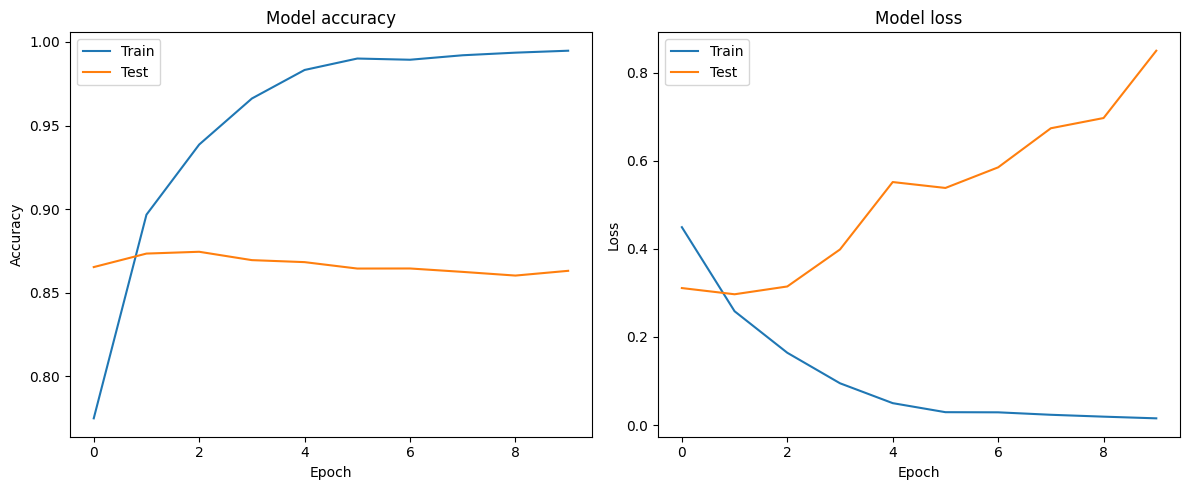

In [7]:
# Step 6: Train the model and capture the history
history = model.fit(X_train, y_train, epochs=10, batch_size=64, validation_data=(X_test, y_test))

# Step 7: Plot the accuracy and loss
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')

plt.tight_layout()
plt.show()

In [8]:
# Function to preprocess and predict sentiment of a given review
def preprocess_review(review):
    # Use the tokenizer to convert the review to a sequence of integers
    tokens = [word_index.get(word, 0) for word in review.lower().split()]
    return pad_sequences([tokens], maxlen=max_len)

def predict_review(review):
    # Preprocess the review and make a prediction
    padded_sequence = preprocess_review(review)
    prediction = model.predict(padded_sequence)

    # Interpret the prediction
    if prediction[0][0] > 0.5:
        return "Positive Review (Score: {:.2f})".format(prediction[0][0])
    else:
        return "Negative Review (Score: {:.2f})".format(1 - prediction[0][0])

# Test the model with sample reviews
sample_reviews = [
    "This movie was fantastic! I loved it.",
    "I didn't like the plot at all. It was boring.",
    "The acting was great, but the story was terrible.",
    "Absolutely wonderful! A must-watch for everyone."
]

# Test the model with sample reviews
for review in sample_reviews:
    result = predict_review(review)
    print(f"Review: \"{review}\" - Prediction: {result}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
Review: "This movie was fantastic! I loved it." - Prediction: Negative Review (Score: 0.55)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
Review: "I didn't like the plot at all. It was boring." - Prediction: Negative Review (Score: 0.81)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
Review: "The acting was great, but the story was terrible." - Prediction: Negative Review (Score: 0.56)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
Review: "Absolutely wonderful! A must-watch for everyone." - Prediction: Negative Review (Score: 0.59)
